Lieferperformance
Reiognale Effekte (logistischer Einflussfaktor)

Warum zusammen?
Region beeinflusst Lieferung.
Region ist kein eigenständiges Geschäftsmodell, sondern ei nTreiber bei der Operational Performance.

In [1]:
import duckdb
from pathlib import Path

# GENAU DERSELBE PFAD wie im ersten Notebook!
DB_PATH = Path("../data/processed/olist.duckdb")

con = duckdb.connect(DB_PATH.as_posix())

def sql(query: str):
    return con.execute(query).df()

# Direkt Tabellen anzeigen/abfragen (kein CSV-Loop nötig!)
sql("SHOW TABLES")
df_orders = sql("SELECT * FROM service_analyse LIMIT 10")
df_orders.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,...,review_answer_timestamp,product_id,product_category_name_english,product_count,seller_id,seller_city,seller_state,customer_city,customer_state,product_category_name_english_1
0,1be187af7e77d6ee0671be02c229b679,delivered,2018-05-30 10:12:07,2018-05-30 10:30:18,2018-06-01 12:54:00,2018-06-14 20:46:56,2018-07-12,696a80628f16220233a31cab1ce3ef30,2,NaN,...,2018-06-16 00:35:17,966746deb2173a72d95ca8b80223f014,bed_bath_table,1,1900267e848ceeba8fa32d80c1a5f5a8,ibitinga,SP,uberlandia,MG,bed_bath_table
1,e11dead0c183b7b8da09f6b3039ea730,delivered,2017-02-09 10:40:05,2017-02-09 10:55:14,2017-02-10 11:09:01,2017-02-14 13:08:44,2017-03-10,3dacc0ba7e4bcfe150e398b01637472b,3,NaN,...,2017-02-16 17:19:49,2fcbaee260e3146369f5e4f2b2abe551,garden_tools,1,5fd924b4836098a5be0ecf81ba054ce0,sao paulo,SP,belo horizonte,MG,garden_tools
2,905f7a43f18905597465564ae6deb958,delivered,2018-08-10 22:59:49,2018-08-14 04:45:20,2018-08-15 05:41:00,2018-08-28 21:41:40,2018-08-30,13164d9da17abb1a513eb773bff4f274,1,Recebi pedido incompleto,...,2018-10-02 20:44:56,51ce083cd2b9078656a94655ab45b8a4,bed_bath_table,1,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,irati,PR,bed_bath_table
3,8283cb8792b84009b158a085333ee8b3,delivered,2018-04-20 08:18:07,2018-04-24 18:14:55,2018-04-23 19:21:04,2018-05-08 16:35:47,2018-05-23,8944a074bce81688fe43eed3b0a4ff1b,4,recomendo,...,2018-05-10 12:13:05,1c47e837f2780378d8485d04ab83a45d,health_beauty,1,094ced053e257ae8cae57205592d6712,ribeirao preto,SP,limoeiro,PE,health_beauty
4,4a5cc9b4e332e03d76bf553a7f2fa5d3,delivered,2017-12-15 23:33:32,2017-12-18 00:33:04,2017-12-19 01:35:09,2018-01-03 23:13:15,2018-01-16,c7e18295d6bec5500da0d9d2ca18ab82,3,NaN,...,2018-01-07 15:14:14,c2ccc78b5a924096d5274ca6a3118e47,health_beauty,1,709e16e2b25c7474d980076c6bfc4806,birigui,SP,belford roxo,RJ,health_beauty


In [2]:
con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

<Axes: >

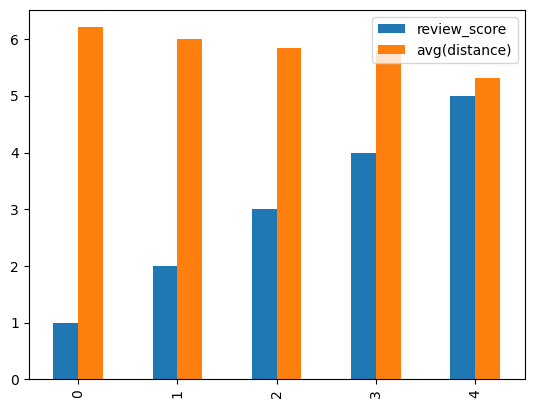

In [3]:
df_geotest = sql("""
WITH geo_unique AS (
    SELECT 
            geolocation_zip_code_prefix,
            AVG(geolocation_lat) AS lat,
            AVG(geolocation_lng) AS lng
    FROM geolocation
    GROUP BY geolocation_zip_code_prefix
),
orders_small AS (
    SELECT * FROM orders -- LIMIT 100000
)
SELECT review_score,
        AVG(distance) FROM 
(SELECT
        o.order_id,       
        c.customer_unique_id[0:5],
        FIRST(c_geo.lat) AS customer_lat,
        FIRST(c_geo.lng) AS customer_lng,
        FIRST(ST_Point(c_geo.lng, c_geo.lat)) AS customer_point,
        s.seller_id[0:5],
        FIRST(s_geo.lat) AS seller_lat,
        FIRST(s_geo.lng) AS seller_lng,
        FIRST(ST_Point(s_geo.lng, s_geo.lat)) AS seller_point,
        r.review_score,
        ST_Distance(FIRST(ST_Point(c_geo.lng, c_geo.lat)), FIRST(ST_Point(s_geo.lng, s_geo.lat))) AS distance
FROM orders_small o
JOIN customers c 
        ON o.customer_id = c.customer_id
JOIN geo_unique c_geo 
        ON c_geo.geolocation_zip_code_prefix = c.customer_zip_code_prefix
JOIN order_items oi 
        ON o.order_id = oi.order_id
JOIN sellers s 
        ON oi.seller_id = s.seller_id
JOIN geo_unique s_geo 
        ON s_geo.geolocation_zip_code_prefix = s.seller_zip_code_prefix
JOIN order_reviews r ON o.order_id = r.order_id
GROUP BY 
        c.customer_unique_id,
        s.seller_id,
        o.order_id,
        r.review_score)
GROUP BY review_score
""")
df_geotest.head(20).plot(kind='bar')

In [22]:
df_distance_test = sql("""

WITH geo_unique AS (
    SELECT 
        geolocation_zip_code_prefix,
        AVG(geolocation_lat) AS lat,
        AVG(geolocation_lng) AS lng
    FROM geolocation
    GROUP BY geolocation_zip_code_prefix
)
SELECT 
    r.review_score,
    AVG(
        ST_Distance_Sphere(
            ST_Point(c_geo.lng, c_geo.lat),
            ST_Point(s_geo.lng, s_geo.lat)
        )
    ) AS avg_distance,

FROM orders o

JOIN customers c 
    ON o.customer_id = c.customer_id

JOIN geo_unique c_geo 
    ON c.customer_zip_code_prefix = c_geo.geolocation_zip_code_prefix

JOIN order_items oi 
    ON o.order_id = oi.order_id

JOIN sellers s 
    ON oi.seller_id = s.seller_id

JOIN geo_unique s_geo 
    ON s.seller_zip_code_prefix = s_geo.geolocation_zip_code_prefix

JOIN order_reviews r 
    ON o.order_id = r.order_id

GROUP BY r.review_score
ORDER BY r.review_score

""")

df_distance_test

,review_score,avg_distance
0,1,565875.213622
1,2,554150.327559
2,3,538593.308877
3,4,532259.039263
4,5,490884.839107


In [23]:
df_distance_test.corr()

,review_score,avg_distance
review_score,1.000000,-0.949375
avg_distance,-0.949375,1.000000


<Axes: xlabel='review_score'>

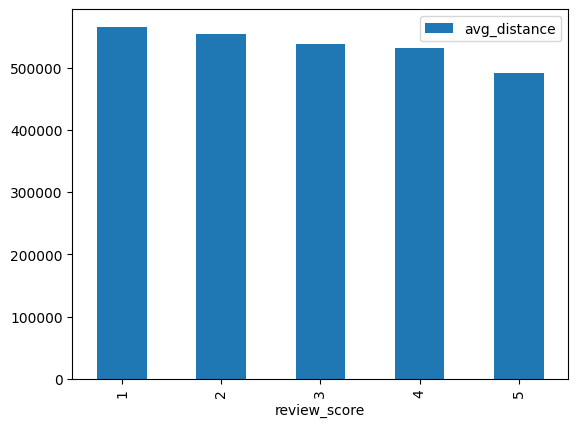

In [24]:
df_distance_test.plot(kind='bar', x='review_score', y='avg_distance')

In [19]:
df_distance = sql("""
WITH geo_unique AS (
    SELECT 
        geolocation_zip_code_prefix,
        AVG(geolocation_lat) AS lat,
        AVG(geolocation_lng) AS lng
    FROM geolocation
    GROUP BY geolocation_zip_code_prefix
),

order_item_distance AS (
    SELECT
        o.order_id,
        r.review_score,
        ST_Distance_Sphere(
            ST_Point(c_geo.lng, c_geo.lat),
            ST_Point(s_geo.lng, s_geo.lat)
        ) AS distance
    FROM orders o

    JOIN customers c 
        ON o.customer_id = c.customer_id

    JOIN geo_unique c_geo 
        ON c.customer_zip_code_prefix = c_geo.geolocation_zip_code_prefix

    JOIN order_items oi 
        ON o.order_id = oi.order_id

    JOIN sellers s 
        ON oi.seller_id = s.seller_id

    JOIN geo_unique s_geo 
        ON s.seller_zip_code_prefix = s_geo.geolocation_zip_code_prefix

    JOIN order_reviews r 
        ON o.order_id = r.order_id
),

order_distance AS (
    SELECT
        order_id,
        review_score,
        MAX(distance) AS max_distance
    FROM order_item_distance
    GROUP BY order_id, review_score
)

SELECT
    review_score,
    AVG(max_distance) AS avg_distance
FROM order_distance
GROUP BY review_score
ORDER BY review_score;
""")
df_distance

,review_score,avg_distance
0,1,585795.895315
1,2,566113.330539
2,3,545246.490803
3,4,536664.646406
4,5,495076.811469


<Axes: xlabel='review_score'>

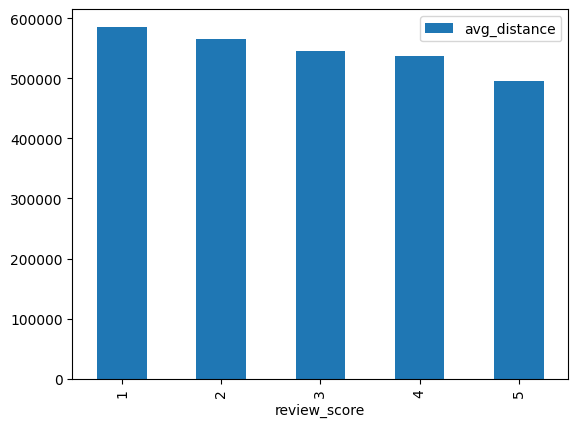

In [20]:
df_distance.plot(kind='bar', x='review_score', y='avg_distance')

In [30]:
test = sql("""
WITH geo_unique AS (
    SELECT 
        geolocation_zip_code_prefix,
        AVG(geolocation_lat) AS lat,
        AVG(geolocation_lng) AS lng
    FROM geolocation
    GROUP BY geolocation_zip_code_prefix
),

order_item_distance AS (
    SELECT
        o.order_id,
        ST_Distance_Sphere(
            ST_Point(c_geo.lng, c_geo.lat),
            ST_Point(s_geo.lng, s_geo.lat)
        ) AS distance
    FROM orders o

    JOIN customers c 
        ON o.customer_id = c.customer_id

    JOIN geo_unique c_geo 
        ON c.customer_zip_code_prefix = c_geo.geolocation_zip_code_prefix

    JOIN order_items oi 
        ON o.order_id = oi.order_id

    JOIN sellers s 
        ON oi.seller_id = s.seller_id

    JOIN geo_unique s_geo 
        ON s.seller_zip_code_prefix = s_geo.geolocation_zip_code_prefix
)

SELECT
    order_id,
    MAX(distance) AS max_distance
FROM order_item_distance
GROUP BY order_id

""")
test

,order_id,max_distance
0,000229ec398224ef6ca0657da4fc703e,2.562756e+05
1,0006ec9db01a64e59a68b2c340bf65a7,6.033680e+05
2,00664284de7a3470d22931ed78615ee4,4.191638e+05
3,008c3a655c66f4d92370d0d422732f69,8.550178e+04
4,00eef7fe9e315a85d1a61a50cccb2494,3.462885e+05
...,...,...
98172,ff9770f7299db492e5fe01b4a231341b,8.244041e+05
98173,ff9a99c60b18acf7c678d38e0549ca67,2.862403e+05
98174,ffa1dd31c0e1fd3a1248fe23238eccd5,3.297303e+05
98175,ffd9fe7f21106081de852f98c6c78dca,1.566118e+06


In [ ]:
con.execute("CREATE TABLE distance AS SELECT * FROM df_distance")

In [26]:
sql("SHOW TABLES")


,name
0,customer_rfm
1,customers
2,distance
3,geolocation
4,order_items
5,order_payments
6,order_reviews
7,orders
8,product_category
9,product_category_name_translation


In [27]:
df_quality_orders = sql(
"""
SELECT * 

FROM service_analyse sa

JOIN distance d
ON sa.order_id = d.order_id
LIMIT 10

""")
df_quality_orders.head()

BinderException: Binder Error: Table "d" does not have a column named "order_id"

Candidate bindings: : "review_score"

LINE 7: ON sa.order_id = d.order_id
                         ^

In [ ]:
# con.close()